# Task 1

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, export_text

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    roc_curve,
    precision_recall_curve
)

RANDOM_STATE = 42

sns.set_theme(style="whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
adult = fetch_openml(
    name="adult",
    version=2,
    as_frame=True
)

df = adult.frame.copy()

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (48842, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


In [4]:
df["target"] = (
    df["class"]
    .astype(str)
    .str.strip()
    .str.replace(".", "", regex=False)
    .map({
        "<=50K": 0,
        ">50K": 1
    })
)

df.drop(columns=["class"], inplace=True)

print(df["target"].value_counts())

target
0    37155
1    11687
Name: count, dtype: int64


In [5]:
categorical_columns_all = df.select_dtypes(
    include=["object", "category"]
).columns

In [9]:
for col in categorical_columns_all:
    question_count = (
        df[col]
        .astype(str)
        .str.strip()
        .eq("?")
        .sum()
    )
    
    if question_count > 0:
        print(col, question_count)

In [10]:
for col in categorical_columns_all:
    df[col] = (
        df[col]
        .astype(object)
        .replace(r"^\s*\?\s*$", np.nan, regex=True)
    )

In [11]:
missing_summary = df.isna().sum()

missing_summary[
    missing_summary > 0
].sort_values(ascending=False)

occupation        2809
workclass         2799
native-country     857
dtype: int64

In [12]:
X = df.drop(columns=["target"])
y = df["target"]

numeric_features = X.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Numeric Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)

print("\nNumber of Numeric Features:", len(numeric_features))
print("Number of Categorical Features:", len(categorical_features))

Numeric Features:
['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']

Categorical Features:
['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']

Number of Numeric Features: 6
Number of Categorical Features: 8


## Build the Preprocessing Pipeline

### Numeric Pipeline

In [14]:
numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

### Numeric Preprocessing Choice

Missing numeric values will be handled using median imputation. The median is more robust to extreme values than the mean, which is useful for features with skewed distributions or outliers. Mean imputation was considered but not selected because features such as capital-gain and capital-loss can contain highly skewed values.

### Categorical Pipeline

In [15]:
categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

### Categorical Preprocessing Choice

Categorical variables will be imputed using the most frequent category and then transformed using One-Hot Encoding. One-Hot Encoding allows machine learning algorithms to use categorical information without incorrectly assuming an ordinal relationship between categories. Ordinal encoding was considered but skipped because categories such as occupation or workclass do not have a meaningful numerical order. The `handle_unknown='ignore'` setting ensures that the pipeline can safely process categories that may appear in new data but were not observed during training.

### Using ColumnTransformer

In [16]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_pipeline,
            numeric_features
        ),
        (
            "cat",
            categorical_pipeline,
            categorical_features
        )
    ]
)

# Task 2

In [17]:
X_train_dev, X_test, y_train_dev, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

In [18]:
X_train, X_dev, y_train, y_dev = train_test_split(
    X_train_dev,
    y_train_dev,
    test_size=0.10,
    stratify=y_train_dev,
    random_state=RANDOM_STATE
)

In [19]:
print("Training:", X_train.shape)
print("Development:", X_dev.shape)
print("Hold-out Test:", X_test.shape)

Training: (35165, 14)
Development: (3908, 14)
Hold-out Test: (9769, 14)


### Model 1: Logistic Regression

In [20]:
logistic_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            LogisticRegression(
                random_state=RANDOM_STATE,
                solver="liblinear",
                max_iter=2000
            )
        )
    ]
)

In [21]:
logistic_pipeline.fit(
    X_train,
    y_train
)

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


### Model 2: Decision Tree

In [22]:
tree_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            DecisionTreeClassifier(
                random_state=RANDOM_STATE
            )
        )
    ]
)

In [23]:
tree_pipeline.fit(
    X_train,
    y_train
)

print("Decision Tree trained successfully!")

Decision Tree trained successfully!


# Task 3

In [24]:
def evaluate_classifier(
    model,
    X_data,
    y_true,
    model_name
):
    
    y_pred = model.predict(X_data)
    
    y_proba = model.predict_proba(
        X_data
    )[:, 1]
    
    results = {
        "Model": model_name,
        "Accuracy": accuracy_score(
            y_true,
            y_pred
        ),
        "Precision": precision_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "F1": f1_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "ROC AUC": roc_auc_score(
            y_true,
            y_proba
        ),
        "PR AUC": average_precision_score(
            y_true,
            y_proba
        )
    }
    
    return results, y_pred, y_proba

In [25]:
logistic_results, y_pred_logistic, y_proba_logistic = (
    evaluate_classifier(
        logistic_pipeline,
        X_test,
        y_test,
        "Logistic Regression"
    )
)

logistic_results

{'Model': 'Logistic Regression',
 'Accuracy': 0.8527996724332071,
 'Precision': 0.7432432432432432,
 'Recall': 0.588109495295124,
 'F1': 0.6566380133715377,
 'ROC AUC': 0.9039803776724767,
 'PR AUC': 0.7626643577564602}

In [26]:
tree_results, y_pred_tree, y_proba_tree = (
    evaluate_classifier(
        tree_pipeline,
        X_test,
        y_test,
        "Decision Tree"
    )
)

tree_results

{'Model': 'Decision Tree',
 'Accuracy': 0.8176886068174839,
 'Precision': 0.6193741963137591,
 'Recall': 0.6180496150556031,
 'F1': 0.6187111967458788,
 'ROC AUC': 0.7492494105162995,
 'PR AUC': 0.4742155917553163}

In [27]:
baseline_majority = {
    "Model": "Majority Class Baseline",
    "Accuracy": 0.7607,
    "Precision": 0.0000,
    "Recall": 0.0000,
    "F1": 0.0000,
    "ROC AUC": 0.5000,
    "PR AUC": np.nan
}

baseline_education = {
    "Model": "Education Rule Baseline",
    "Accuracy": 0.7530,
    "Precision": 0.4844,
    "Recall": 0.4970,
    "F1": 0.4906,
    "ROC AUC": 0.7189,
    "PR AUC": 0.4443
}

In [28]:
comparison_results = pd.DataFrame([
    baseline_majority,
    baseline_education,
    logistic_results,
    tree_results
])

comparison_results

,Model,Accuracy,Precision,Recall,F1,ROC AUC,PR AUC
0,Majority Class Baseline,0.760700,0.000000,0.000000,0.000000,0.500000,NaN
1,Education Rule Baseline,0.753000,0.484400,0.497000,0.490600,0.718900,0.444300
2,Logistic Regression,0.852800,0.743243,0.588109,0.656638,0.903980,0.762664
3,Decision Tree,0.817689,0.619374,0.618050,0.618711,0.749249,0.474216


In [29]:
display(
    comparison_results.style.format({
        "Accuracy": "{:.2%}",
        "Precision": "{:.2%}",
        "Recall": "{:.2%}",
        "F1": "{:.2%}",
        "ROC AUC": "{:.2%}",
        "PR AUC": "{:.2%}"
    })
)

,Model,Accuracy,Precision,Recall,F1,ROC AUC,PR AUC
0,Majority Class Baseline,76.07%,0.00%,0.00%,0.00%,50.00%,nan%
1,Education Rule Baseline,75.30%,48.44%,49.70%,49.06%,71.89%,44.43%
2,Logistic Regression,85.28%,74.32%,58.81%,65.66%,90.40%,76.27%
3,Decision Tree,81.77%,61.94%,61.80%,61.87%,74.92%,47.42%


### Model Comparison Interpretation

Logistic Regression performed the best among the two supervised models on the hold-out test set. It achieved an accuracy of 85.28%, precision of 74.32%, recall of 58.81%, F1-score of 65.66%, ROC AUC of 90.40%, and PR AUC of 76.27%. Decision Tree achieved an accuracy of 81.77%, precision of 61.94%, recall of 61.80%, F1-score of 61.87%, ROC AUC of 74.92%, and PR AUC of 47.42%. Both supervised models substantially improved on the Day 1 Education Rule Baseline, which had 75.30% accuracy, 48.44% precision, 49.70% recall, 49.06% F1, 71.89% ROC AUC, and 44.43% PR AUC. Logistic Regression improved precision from 48.44% to 74.32%, which is a substantial improvement over the primary precision benchmark. Decision Tree also improved precision to 61.94%. Therefore, both models are useful compared with the simple baselines, but Logistic Regression provides the strongest overall performance, especially for the business objective of making more reliable positive predictions.

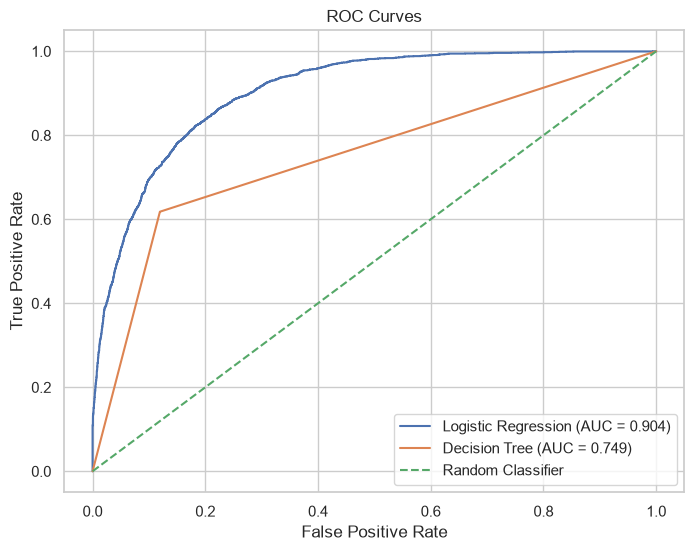

In [30]:
plt.figure(figsize=(8, 6))

fpr_logistic, tpr_logistic, _ = roc_curve(
    y_test,
    y_proba_logistic
)

fpr_tree, tpr_tree, _ = roc_curve(
    y_test,
    y_proba_tree
)

plt.plot(
    fpr_logistic,
    tpr_logistic,
    label=(
        f"Logistic Regression "
        f"(AUC = {logistic_results['ROC AUC']:.3f})"
    )
)

plt.plot(
    fpr_tree,
    tpr_tree,
    label=(
        f"Decision Tree "
        f"(AUC = {tree_results['ROC AUC']:.3f})"
    )
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()

plt.show()

### Precision–Recall Curves

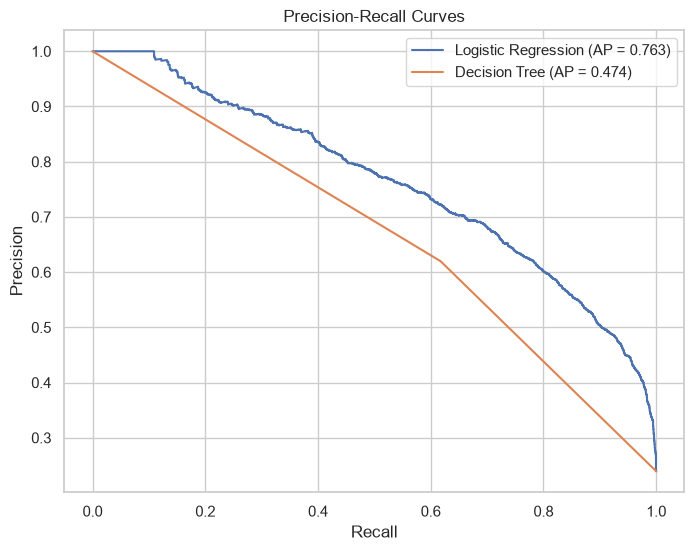

In [31]:
plt.figure(figsize=(8, 6))

precision_logistic, recall_logistic, _ = (
    precision_recall_curve(
        y_test,
        y_proba_logistic
    )
)

precision_tree, recall_tree, _ = (
    precision_recall_curve(
        y_test,
        y_proba_tree
    )
)

plt.plot(
    recall_logistic,
    precision_logistic,
    label=(
        f"Logistic Regression "
        f"(AP = {logistic_results['PR AUC']:.3f})"
    )
)

plt.plot(
    recall_tree,
    precision_tree,
    label=(
        f"Decision Tree "
        f"(AP = {tree_results['PR AUC']:.3f})"
    )
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves")

plt.legend()

plt.show()

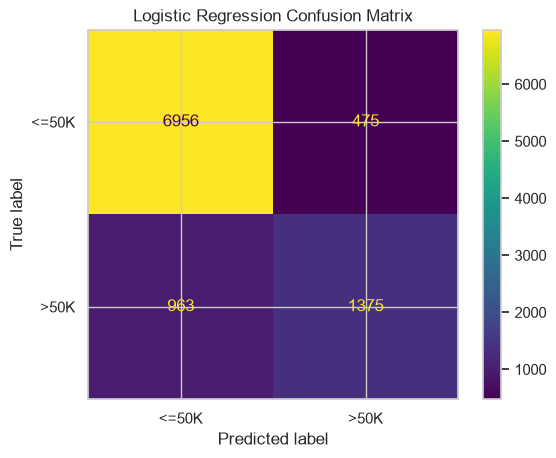

In [32]:
cm_logistic = confusion_matrix(
    y_test,
    y_pred_logistic
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_logistic,
    display_labels=[
        "<=50K",
        ">50K"
    ]
)

disp.plot()

plt.title(
    "Logistic Regression Confusion Matrix"
)

plt.show()

### Logistic Regression

The Logistic Regression confusion matrix contains 6,956 true negatives, 475 false positives, 963 false negatives, and 1,375 true positives. The model therefore correctly identified 6,956 individuals who actually belonged to the <=50K class and 1,375 individuals who actually belonged to the >50K class. It incorrectly classified 475 lower-income individuals as high-income, creating false positives, and missed 963 actual high-income individuals, creating false negatives. The number of false negatives is higher than the number of false positives. This means the model is relatively conservative when predicting the positive class: when it predicts >50K, its precision is high at 74.32%, but it still misses a considerable number of actual positive cases, which contributes to its recall of 58.81%. This behavior supports the business goal because false positives represent wasted outreach, and Logistic Regression keeps false positives relatively low while achieving substantially higher precision than the Day 1 benchmark.

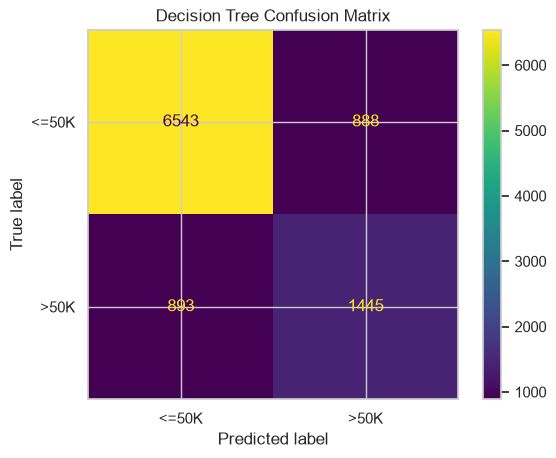

In [33]:
cm_tree = confusion_matrix(
    y_test,
    y_pred_tree
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_tree,
    display_labels=[
        "<=50K",
        ">50K"
    ]
)

disp.plot()

plt.title(
    "Decision Tree Confusion Matrix"
)

plt.show()

### Decision Tree

The Decision Tree confusion matrix contains 6,543 true negatives, 888 false positives, 893 false negatives, and 1,445 true positives. The model correctly identified 6,543 lower-income individuals and 1,445 high-income individuals. It incorrectly classified 888 lower-income individuals as high-income and missed 893 actual high-income individuals. Unlike Logistic Regression, the Decision Tree has almost equal numbers of false positives and false negatives, with false negatives being only slightly higher. Its higher number of false positives contributes to its lower precision of 61.94%, meaning that a larger proportion of its positive predictions are incorrect compared with Logistic Regression. Its recall is slightly higher at 61.80%, because it identifies more actual positive cases. However, given that precision is the primary business metric, the additional false positives make the Decision Tree less attractive for the current objective.

### Confusion Matrix Comparison

Overall, Logistic Regression produces fewer false positives (475 versus 888) and achieves substantially higher precision (74.32% versus 61.94%) than the Decision Tree. The Decision Tree produces fewer false negatives (893 versus 963) and therefore has slightly higher recall (61.80% versus 58.81%). This shows the trade-off between precision and recall: the Decision Tree identifies slightly more positive cases, but it does so at the cost of substantially more false-positive predictions. Since the business objective prioritizes reducing wasted outreach, Logistic Regression is preferable.

### Compare FP and FN

In [34]:
def get_error_counts(y_true, y_pred):
    
    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred
    ).ravel()
    
    return {
        "True Negatives": tn,
        "False Positives": fp,
        "False Negatives": fn,
        "True Positives": tp
    }


logistic_errors = get_error_counts(
    y_test,
    y_pred_logistic
)

tree_errors = get_error_counts(
    y_test,
    y_pred_tree
)

print("Logistic Regression Errors:")
print(logistic_errors)

print("\nDecision Tree Errors:")
print(tree_errors)

Logistic Regression Errors:
{'True Negatives': np.int64(6956), 'False Positives': np.int64(475), 'False Negatives': np.int64(963), 'True Positives': np.int64(1375)}

Decision Tree Errors:
{'True Negatives': np.int64(6543), 'False Positives': np.int64(888), 'False Negatives': np.int64(893), 'True Positives': np.int64(1445)}


# Task 4

In [35]:
preprocessor_fitted = (
    logistic_pipeline.named_steps[
        "preprocessor"
    ]
)

feature_names = (
    preprocessor_fitted
    .get_feature_names_out()
)

In [36]:
print(
    "Number of transformed features:",
    len(feature_names)
)

feature_names[:20]

Number of transformed features: 105


array(['num__age', 'num__fnlwgt', 'num__education-num',
       'num__capital-gain', 'num__capital-loss', 'num__hours-per-week',
       'cat__workclass_Federal-gov', 'cat__workclass_Local-gov',
       'cat__workclass_Never-worked', 'cat__workclass_Private',
       'cat__workclass_Self-emp-inc', 'cat__workclass_Self-emp-not-inc',
       'cat__workclass_State-gov', 'cat__workclass_Without-pay',
       'cat__education_10th', 'cat__education_11th',
       'cat__education_12th', 'cat__education_1st-4th',
       'cat__education_5th-6th', 'cat__education_7th-8th'], dtype=object)

In [37]:
logistic_model = (
    logistic_pipeline.named_steps[
        "model"
    ]
)

coefficients = logistic_model.coef_[0]

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

In [38]:
coef_df = coef_df.sort_values(
    by="Coefficient",
    ascending=False
)

coef_df.head(10)

,Feature,Coefficient
3,num__capital-gain,2.230889
32,cat__marital-status_Married-civ-spouse,1.567475
31,cat__marital-status_Married-AF-spouse,1.199402
84,cat__native-country_Ireland,0.979611
73,cat__native-country_France,0.822141
72,cat__native-country_England,0.815148
40,cat__occupation_Exec-managerial,0.792991
56,cat__relationship_Wife,0.759295
2,num__education-num,0.756891
64,cat__native-country_Cambodia,0.723459


In [39]:
top_positive = (
    coef_df
    .head(10)
    .reset_index(drop=True)
)

top_positive

,Feature,Coefficient
0,num__capital-gain,2.230889
1,cat__marital-status_Married-civ-spouse,1.567475
2,cat__marital-status_Married-AF-spouse,1.199402
3,cat__native-country_Ireland,0.979611
4,cat__native-country_France,0.822141
5,cat__native-country_England,0.815148
6,cat__occupation_Exec-managerial,0.792991
7,cat__relationship_Wife,0.759295
8,num__education-num,0.756891
9,cat__native-country_Cambodia,0.723459


In [40]:
top_negative = (
    coef_df
    .tail(10)
    .sort_values(
        by="Coefficient",
        ascending=True
    )
    .reset_index(drop=True)
)

top_negative

,Feature,Coefficient
0,cat__occupation_Priv-house-serv,-1.410311
1,cat__marital-status_Never-married,-1.217302
2,cat__native-country_Columbia,-1.152273
3,cat__sex_Female,-1.002412
4,cat__relationship_Other-relative,-0.944528
5,cat__native-country_Trinadad&Tobago,-0.934737
6,cat__occupation_Farming-fishing,-0.903380
7,cat__native-country_South,-0.879803
8,cat__occupation_Other-service,-0.872285
9,cat__relationship_Own-child,-0.837274


In [41]:
coef_df["Feature"] = (
    coef_df["Feature"]
    .str.replace(
        "num__",
        "",
        regex=False
    )
    .str.replace(
        "cat__",
        "",
        regex=False
    )
)

In [42]:
top_positive = (
    coef_df
    .sort_values(
        by="Coefficient",
        ascending=False
    )
    .head(10)
)

top_negative = (
    coef_df
    .sort_values(
        by="Coefficient",
        ascending=True
    )
    .head(10)
)

print("Top 10 Positive Coefficients:")
display(top_positive)

print("\nTop 10 Negative Coefficients:")
display(top_negative)

Top 10 Positive Coefficients:


,Feature,Coefficient
3,capital-gain,2.230889
32,marital-status_Married-civ-spouse,1.567475
31,marital-status_Married-AF-spouse,1.199402
84,native-country_Ireland,0.979611
73,native-country_France,0.822141
72,native-country_England,0.815148
40,occupation_Exec-managerial,0.792991
56,relationship_Wife,0.759295
2,education-num,0.756891
64,native-country_Cambodia,0.723459



Top 10 Negative Coefficients:


,Feature,Coefficient
45,occupation_Priv-house-serv,-1.410311
34,marital-status_Never-married,-1.217302
67,native-country_Columbia,-1.152273
62,sex_Female,-1.002412
53,relationship_Other-relative,-0.944528
101,native-country_Trinadad&Tobago,-0.934737
41,occupation_Farming-fishing,-0.903380
98,native-country_South,-0.879803
44,occupation_Other-service,-0.872285
54,relationship_Own-child,-0.837274


### Decision Tree Analysis

In [43]:
tree_model = (
    tree_pipeline.named_steps[
        "model"
    ]
)

print(
    "Tree Depth:",
    tree_model.get_depth()
)

print(
    "Number of Leaves:",
    tree_model.get_n_leaves()
)

Tree Depth: 59
Number of Leaves: 5100


### Train vs Test Score

In [44]:
train_score_tree = tree_pipeline.score(
    X_train,
    y_train
)

test_score_tree = tree_pipeline.score(
    X_test,
    y_test
)

print(
    f"Training Accuracy: "
    f"{train_score_tree:.4f}"
)

print(
    f"Test Accuracy: "
    f"{test_score_tree:.4f}"
)

Training Accuracy: 0.9999
Test Accuracy: 0.8177


In [45]:
tree_feature_names = (
    tree_pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

In [46]:
tree_structure = tree_model.tree_

In [47]:
split_information = []

for node_id in range(
    tree_structure.node_count
):
    
    feature_index = (
        tree_structure.feature[node_id]
    )
    
    if feature_index >= 0:
        
        split_information.append({
            "Node": node_id,
            "Feature": (
                tree_feature_names[
                    feature_index
                ]
            ),
            "Threshold": (
                tree_structure.threshold[
                    node_id
                ]
            ),
            "Samples": (
                tree_structure.n_node_samples[
                    node_id
                ]
            )
        })

In [48]:
top_3_splits = pd.DataFrame(
    split_information
).head(3)

top_3_splits

,Node,Feature,Threshold,Samples
0,0,cat__marital-status_Married-civ-spouse,0.500000,35165
1,1,num__capital-gain,0.821219,19131
2,2,num__education-num,0.938797,18811


# Task 5

### Model Selection for Day 3

For Day 3, I will continue primarily with Logistic Regression because it performed best on the hold-out test set and aligns most closely with the business objective of improving precision. Logistic Regression achieved 74.32% precision, compared with 61.94% for the Decision Tree and 48.44% for the Day 1 Education Rule Baseline. It also achieved the highest accuracy (85.28%), F1-score (65.66%), ROC AUC (90.40%), and PR AUC (76.27%) among the evaluated models. Its false-positive count was also substantially lower than the Decision Tree's (475 versus 888). These results indicate that Logistic Regression provides more reliable positive predictions and better overall ranking performance for this task.

I will also keep the Decision Tree as a useful comparison model because it provides nonlinear decision rules and can capture feature interactions that Logistic Regression may not capture directly. Its recall of 61.80% was slightly higher than Logistic Regression's 58.81%, and it identified more true positives (1,445 versus 1,375). However, the tree clearly overfits the training data, with 99.99% training accuracy compared with 81.77% test accuracy, so future work should focus on controlling its complexity before considering it as the main model.

In [50]:
tree_rules = export_text(
    tree_model,
    feature_names=list(
        tree_feature_names
    ),
    max_depth=3
)

print(tree_rules)

|--- cat__marital-status_Married-civ-spouse <= 0.50
|   |--- num__capital-gain <= 0.82
|   |   |--- num__education-num <= 0.94
|   |   |   |--- num__capital-loss <= 5.21
|   |   |   |   |--- truncated branch of depth 23
|   |   |   |--- num__capital-loss >  5.21
|   |   |   |   |--- truncated branch of depth 9
|   |   |--- num__education-num >  0.94
|   |   |   |--- num__age <= -0.52
|   |   |   |   |--- truncated branch of depth 28
|   |   |   |--- num__age >  -0.52
|   |   |   |   |--- truncated branch of depth 30
|   |--- num__capital-gain >  0.82
|   |   |--- num__age <= -1.32
|   |   |   |--- num__fnlwgt <= -0.23
|   |   |   |   |--- class: 1
|   |   |   |--- num__fnlwgt >  -0.23
|   |   |   |   |--- class: 0
|   |   |--- num__age >  -1.32
|   |   |   |--- num__capital-gain <= 0.99
|   |   |   |   |--- truncated branch of depth 4
|   |   |   |--- num__capital-gain >  0.99
|   |   |   |   |--- truncated branch of depth 4
|--- cat__marital-status_Married-civ-spouse >  0.50
|   |--- 

### Preprocessing Changes for Tomorrow

For Day 3, I plan to test the following preprocessing and modeling improvements:

1. Alternative missing-value handling: Compare the current median imputation for numeric variables with other reasonable strategies where appropriate.
2. Explicit missing categories: Test whether replacing missing categorical values with an explicit "Missing" category provides useful information instead of using only the most frequent category.
3. Log transformation of capital features: Investigate transformations for highly skewed variables such as capital-gain and capital-loss, while handling their many zero values appropriately.
4. Class weighting: Test whether class weighting can improve the balance between precision and recall for the positive >50K class.
5. Feature redundancy: Investigate overlapping information between features such as education and education-num and determine whether removing redundant information improves the model.
6. Hyperparameter tuning: Tune model parameters, particularly Decision Tree complexity parameters such as max_depth, min_samples_split, and min_samples_leaf, using appropriate validation rather than the hold-out test set.

### Final Day 2 Conclusion

Day 2 established a complete preprocessing and modeling workflow using separate numeric and categorical pipelines combined through ColumnTransformer and model pipelines. Missing categorical values represented by ? were converted to missing values, numeric variables were median-imputed and standardized, and categorical variables were imputed using the most frequent category and One-Hot encoded. Logistic Regression and Decision Tree were then trained using the training data and evaluated on the untouched hold-out test set. Logistic Regression achieved the best overall performance, with 85.28% accuracy, 74.32% precision, 58.81% recall, 65.66% F1, 90.40% ROC AUC, and 76.27% PR AUC, substantially exceeding the Day 1 precision benchmark of 48.44%. The Decision Tree achieved 81.77% accuracy and 61.94% precision, but its 99.99% training accuracy versus 81.77% test accuracy indicates substantial overfitting. Therefore, Day 3 will primarily continue with Logistic Regression while also exploring controlled Decision Tree complexity and improvements to preprocessing, feature representation, class handling, and hyperparameters.